# MDA-mini walkthrough: every component, end to end

This notebook exercises **every contract in `src/mda/interfaces.py`** on a dummy
world — a simple pendulum — and hand-rolls the full MDA loop
(design → observe → infer → expand) so you can watch each piece do its job.

The arc:

1. **World** — a pendulum whose *true* period law carries a large-amplitude
   correction: $T = 2\pi\sqrt{L/g}\,\bigl(1 + \theta_0^2/16\bigr)$. Our starting
   hypotheses won't know about the correction. That's deliberate: the truth
   starts **outside the hypothesis class (M-open)**, which is the regime the
   paper is about.
2. **Hypotheses** — candidate structures with parameters and priors.
3. **Inference** — fit each structure; get a posterior *and* a log evidence.
4. **Design (VoI)** — run the experiment the current pool is most uncertain about.
5. **Proposer** — expands the pool when a predictive check says it's inadequate.
6. **The loop** — everything together, then evaluation on held-out interventions.

Stubs stand in for the expensive parts (prior importance sampling instead of SMC,
a scripted proposer instead of an LLM). **The contracts are the real ones** — every
class defined here satisfies a protocol from `interfaces.py`, checked with
`isinstance` as we go.

## The shape of the system

One round of Algorithm 1. Solid arrows are the main data flow; the dashed arrow
is the M-open escape hatch; dotted arrows are cost accounting.

In [ ]:
from dataclasses import dataclass, field
from typing import Callable, Optional, Sequence

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import sympy

RNG = np.random.Generator

from mda import (
    AgentConfig, CostLedger, Design, Designer, GaussianNoise, Hypothesis,
    HypothesisState, InferenceEngine, NoiseModel, Observation, Posterior,
    Proposer, World, normalize_pool,
)
from mda.stubs import PriorISEngine

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

# One fixed color per entity, used consistently in every chart below
# (CVD-validated Okabe-Ito subset; vermillion is reserved for thresholds).
C = {"linear": "#E69F00", "power-law": "#0072B2", "power-law-amp": "#CC79A7",
     "truth": "#333333", "data": "#111111", "threshold": "#D55E00"}

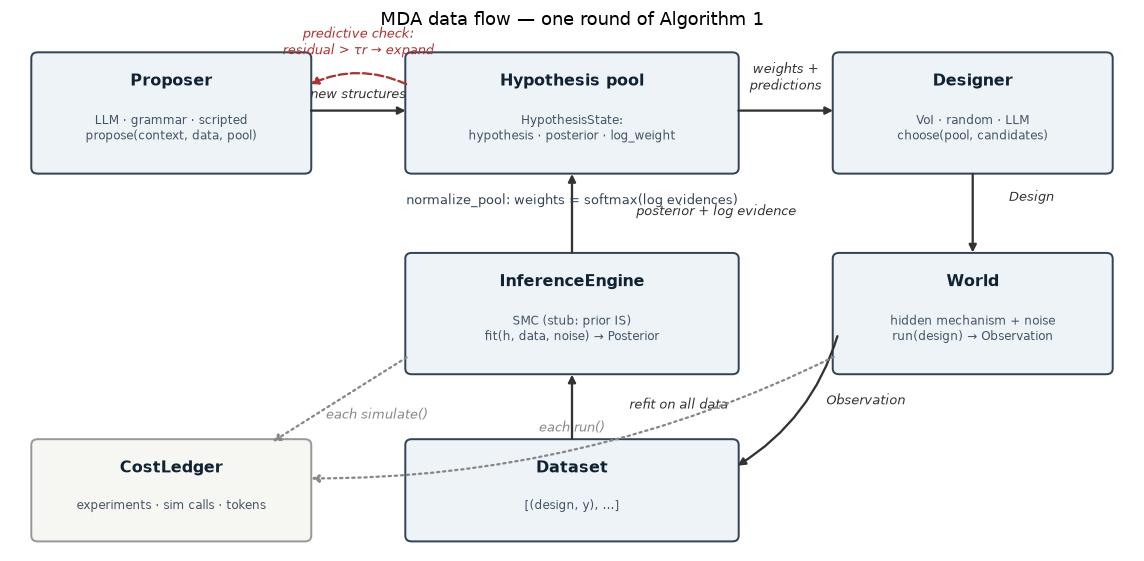

In [5]:
def _box(ax, x, y, w, h, title, sub, fc="#eef3f8", ec="#345"):
    ax.add_patch(mpatches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.06",
                                         fc=fc, ec=ec, lw=1.3))
    ax.text(x + w/2, y + h - 0.16, title, ha="center", va="top",
            fontsize=10.5, weight="bold", color="#123")
    ax.text(x + w/2, y + h/2 - 0.16, sub, ha="center", va="center",
            fontsize=8, color="#456")

def _arrow(ax, p, q, label="", curve=0.0, ls="-", color="#333", lox=0, loy=0.13):
    ax.annotate("", xy=q, xytext=p, arrowprops=dict(
        arrowstyle="-|>", color=color, lw=1.5, ls=ls,
        connectionstyle=f"arc3,rad={curve}", shrinkA=4, shrinkB=4))
    if label:
        ax.text((p[0]+q[0])/2 + lox, (p[1]+q[1])/2 + loy, label,
                ha="center", fontsize=8.2, color=color, style="italic")

fig, ax = plt.subplots(figsize=(10.5, 5.2))
ax.set_xlim(0, 10.5); ax.set_ylim(0, 5.4); ax.axis("off"); ax.grid(False)

_box(ax, 0.25, 4.0, 2.5, 1.15, "Proposer",  "LLM · grammar · scripted\npropose(context, data, pool)")
_box(ax, 3.75, 4.0, 3.0, 1.15, "Hypothesis pool", "HypothesisState:\nhypothesis · posterior · log_weight")
_box(ax, 7.75, 4.0, 2.5, 1.15, "Designer",  "VoI · random · LLM\nchoose(pool, candidates)")
_box(ax, 7.75, 1.9, 2.5, 1.15, "World",     "hidden mechanism + noise\nrun(design) → Observation")
_box(ax, 3.75, 1.9, 3.0, 1.15, "InferenceEngine", "SMC (stub: prior IS)\nfit(h, data, noise) → Posterior")
_box(ax, 3.75, 0.15, 3.0, 0.95, "Dataset",  "[(design, y), …]")
_box(ax, 0.25, 0.15, 2.5, 0.95, "CostLedger", "experiments · sim calls · tokens",
     fc="#f6f6f2", ec="#999")

_arrow(ax, (2.75, 4.6), (3.75, 4.6),  "new structures")
_arrow(ax, (6.75, 4.6), (7.75, 4.6),  "weights +\npredictions", loy=0.22)
_arrow(ax, (9.0, 4.0),  (9.0, 3.05),  "Design", lox=0.55)
_arrow(ax, (7.75, 2.3), (6.75, 0.85), "Observation", curve=-0.2, lox=0.75, loy=-0.05)
_arrow(ax, (5.25, 1.1), (5.25, 1.9),  "refit on all data", lox=1.0, loy=-0.02)
_arrow(ax, (5.25, 3.05),(5.25, 4.0),  "posterior + log evidence", lox=1.35, loy=-0.02)
_arrow(ax, (3.75, 4.85),(2.75, 4.85), "predictive check:\nresidual > τr → expand",
       ls="--", color="#a33", curve=0.25, loy=0.34)
_arrow(ax, (7.75, 2.05),(2.75, 0.75), "each run()", ls=":", color="#888", curve=-0.12, loy=-0.16)
_arrow(ax, (3.75, 2.05),(2.4, 1.1),   "each simulate()", ls=":", color="#888", loy=-0.2, lox=0.35)
ax.text(5.25, 3.62, "normalize_pool: weights = softmax(log evidences)",
        ha="center", fontsize=8.2, color="#345")
ax.set_title("MDA data flow — one round of Algorithm 1", fontsize=12, pad=6)
plt.tight_layout()

## 1 · World — the environment we experiment on

The `World` protocol is the benchmark environment: a hidden mechanism, a discrete
menu of interventions (`design_space`), noisy execution (`run`), a natural-language
`description()` for the proposer, and held-out `test_designs()` used only for
evaluation.

Our dummy world: set rod length $L$ and release amplitude $\theta_0$, measure the
period $T$. Ground truth (the world knows it; the agent never sees it):

$$T \;=\; 2\pi\sqrt{L/g}\;\Bigl(1 + \tfrac{\theta_0^2}{16}\Bigr) \;+\; \varepsilon,
\qquad \varepsilon \sim \mathcal N(0,\, 0.05^2)$$

The $\theta_0^2/16$ factor is the first large-amplitude correction to the
small-angle law — the trap we set for our initial hypotheses.

In [ ]:
G = 9.81

@dataclass
class PendulumWorld:
    sigma: float = 0.05
    lengths: tuple = (0.25, 0.5, 1.0, 1.5, 2.0)
    amplitudes: tuple = (0.15, 0.7, 1.3)      # radians
    name: str = "pendulum"

    def __post_init__(self):
        self.noise = GaussianNoise(self.sigma)

    def description(self) -> str:
        return ("A weight swings on a rigid rod. You may set the rod length L (meters) "
                "and the release angle theta0 (radians), then measure the period T "
                "(seconds) of one full swing. Measurement noise is Gaussian. "
                "The law relating (L, theta0) to T is unknown.")

    def design_space(self) -> list[Design]:
        return [Design.from_dict({"L": L, "theta0": a}, name=f"L={L:g} th0={a:g}")
                for L in self.lengths for a in self.amplitudes]

    def _truth(self, design: Design):
        L, a = design["L"], design["theta0"]
        return np.array([2*np.pi*np.sqrt(L/G) * (1 + a**2/16)])

    def run(self, design: Design, rng: RNG) -> Observation:
        return Observation(design=design, y=self.noise.sample(self._truth(design), rng))

    def test_designs(self):
        # held-out interventions, deliberately including extrapolation in L
        return [Design.from_dict({"L": 3.0,  "theta0": 0.15}, name="L=3 th0=0.15"),
                Design.from_dict({"L": 3.0,  "theta0": 1.3},  name="L=3 th0=1.3"),
                Design.from_dict({"L": 0.75, "theta0": 1.0},  name="L=0.75 th0=1")]

world = PendulumWorld()
assert isinstance(world, World)          # satisfies the protocol
print(world.description())
print(f"\n{len(world.design_space())} designs available, e.g. {world.design_space()[0]}")

A weight swings on a rigid rod. You may set the rod length L (meters) and the release angle theta0 (radians), then measure the period T (seconds) of one full swing. Measurement noise is Gaussian. The law relating (L, theta0) to T is unknown.

15 designs available, e.g. Design(params=(('L', 0.25), ('theta0', 0.15)), name='L=0.25 th0=0.15')


In [4]:
Observation

mda.interfaces.Observation

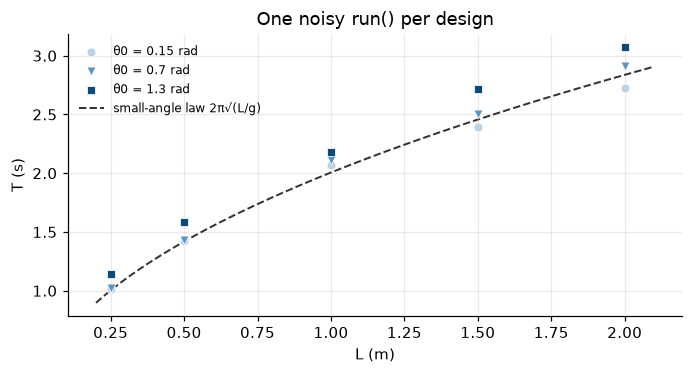

In [4]:
demo_rng = np.random.default_rng(0)
demo_obs = [world.run(d, demo_rng) for d in world.design_space()]

fig, ax = plt.subplots(figsize=(6.4, 3.5))
shades = {0.15: "#bcd2e8", 0.7: "#5b93c4", 1.3: "#0b4a79"}   # one hue, light->dark in th0
for a, mk in zip(world.amplitudes, "ovs"):
    pts = [(o.design["L"], o.y[0]) for o in demo_obs if o.design["theta0"] == a]
    ax.scatter(*zip(*pts), marker=mk, s=34, color=shades[a], ec="white", lw=0.5,
               label=f"θ0 = {a} rad", zorder=3)
Ls = np.linspace(0.2, 2.1, 100)
ax.plot(Ls, 2*np.pi*np.sqrt(Ls/G), ls="--", lw=1.3, color=C["truth"],
        label="small-angle law 2π√(L/g)")
ax.set(xlabel="L (m)", ylabel="T (s)", title="One noisy run() per design")
ax.legend(fontsize=8, frameon=False)
plt.tight_layout()

Already visible: the $\theta_0 = 1.3$ measurements sit systematically **above**
the small-angle curve, and the gap grows with $L$. That systematic misfit is what
the predictive check will eventually catch.

## 2 · Hypothesis — one candidate structure, parameters in a flat vector

A `Hypothesis` is a *structure* (the symbolic form) with free parameters $\theta$
and a prior. The split matters: **structures come from the Proposer, parameters
from the InferenceEngine** — one engine serves any structure it's handed.

`FormulaHypothesis` below wraps any closed-form law into the protocol. Three
candidates, roughly what an LLM might propose from the world description:

| name | law | expresses $\theta_0$? |
|---|---|---|
| `linear` | $T = c_0 + c_1 L$ | no |
| `power-law` | $T = c_0\,L^{c_1}$ | no |
| `power-law-amp` | $T = c_0\,L^{c_1}\,(1 + c_2\,\theta_0^2)$ | **yes** |

The third is the "discovery." We withhold it until the data demands expansion.

In [5]:
@dataclass
class FormulaHypothesis(Hypothesis):
    """Wrap a closed-form law into the Hypothesis protocol.
    Gaussian priors N(prior_mean, prior_scale^2) per parameter."""
    name: str
    prior_mean: np.ndarray
    prior_scale: np.ndarray
    fn: Callable                      # (Design, theta) -> float
    expr: sympy.Expr                  # for eval's symbolic-equivalence check
    ledger: Optional[CostLedger] = None

    @property
    def n_params(self): return len(self.prior_mean)
    @property
    def param_names(self): return [f"c{k}" for k in range(self.n_params)]

    def sample_prior(self, rng, n):
        return self.prior_mean + self.prior_scale * rng.standard_normal((n, self.n_params))

    def log_prior(self, theta):
        z = (np.asarray(theta, float) - self.prior_mean) / self.prior_scale
        return float(-0.5*np.sum(z**2) - np.sum(np.log(self.prior_scale))
                     - 0.5*self.n_params*np.log(2*np.pi))

    def simulate(self, design, theta):
        if self.ledger is not None:
            self.ledger.add_sim()
        return np.array([self.fn(design, np.asarray(theta, float))])

    def sympy_form(self): return self.expr

    def human_description(self) -> str:
        return f"{self.name}: y = {self.expr}. Predictions exclude observation noise."


L_, th0_, c0_, c1_, c2_ = sympy.symbols("L theta0 c0 c1 c2")

def make_linear(ledger=None):
    return FormulaHypothesis("linear", np.array([0.0, 1.0]), np.array([2.0, 1.0]),
        lambda d, c: c[0] + c[1]*d["L"], c0_ + c1_*L_, ledger)

def make_power(ledger=None):
    return FormulaHypothesis("power-law", np.array([2.0, 0.5]), np.array([1.0, 0.4]),
        lambda d, c: c[0]*d["L"]**c[1], c0_*L_**c1_, ledger)

def make_power_amp(ledger=None):
    return FormulaHypothesis("power-law-amp",
        np.array([2.0, 0.5, 0.0]), np.array([1.0, 0.4, 0.3]),
        lambda d, c: c[0]*d["L"]**c[1]*(1 + c[2]*d["theta0"]**2),
        c0_*L_**c1_*(1 + c2_*th0_**2), ledger)

h_lin, h_pow = make_linear(), make_power()
assert isinstance(h_pow, Hypothesis)
h_pow.sympy_form()

L**c1*c0

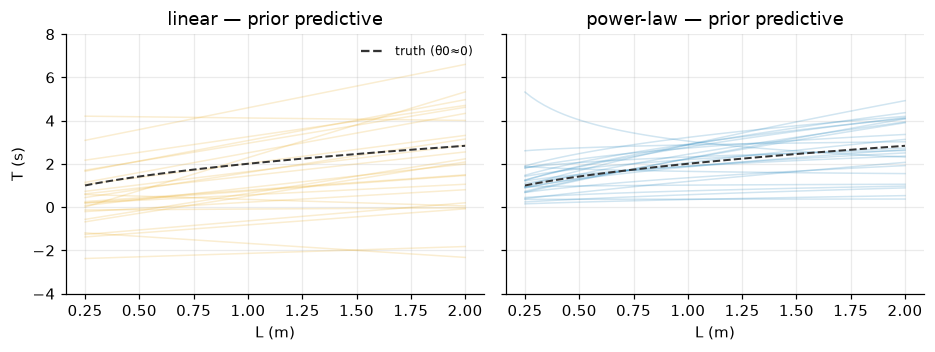

In [6]:
# Prior predictive: what each structure believes before any data
fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.3), sharey=True)
Ls = np.linspace(0.25, 2.0, 60)
prior_rng = np.random.default_rng(1)
for ax, h in zip(axes, [h_lin, h_pow]):
    for th in h.sample_prior(prior_rng, 25):
        ax.plot(Ls, [h.simulate(Design.from_dict({"L": l, "theta0": 0.15}), th)[0]
                     for l in Ls], color=C[h.name], alpha=0.18, lw=1)
    ax.plot(Ls, 2*np.pi*np.sqrt(Ls/G), ls="--", lw=1.3, color=C["truth"])
    ax.set(title=f"{h.name} — prior predictive", xlabel="L (m)", ylim=(-4, 8))
axes[0].set_ylabel("T (s)")
axes[0].plot([], [], ls="--", color=C["truth"], label="truth (θ0≈0)")
axes[0].legend(fontsize=8, frameon=False)
plt.tight_layout()

## 3 · InferenceEngine — posterior *and* evidence for each structure

`fit(hypothesis, data, noise) → Posterior` returns two things:

* the **parameter posterior** — `predict(design)` gives posterior-predictive
  mean/variance of the noise-free outcome (what VoI and evaluation consume), and
* the **log evidence** $\log p(\text{data} \mid \text{structure})$ — the number
  that ranks structures, with its built-in Occam penalty (sanity check (b)).

The stub engine is importance sampling from the prior: honest but doomed. As data
accumulates the posterior concentrates and the **effective sample size (ESS)
collapses** — watch the numbers below. That collapse is exactly why Stage B
replaces this stub with adaptive-tempered SMC *behind the same contract*.

In [7]:
engine = PriorISEngine(n_samples=3000)
assert isinstance(engine, InferenceEngine)

fit_rng = np.random.default_rng(2)
small_designs = [d for d in world.design_space() if d["theta0"] == 0.15]
fit_data = [world.run(d, fit_rng) for d in small_designs]      # 5 small-angle obs

post_lin = engine.fit(h_lin, fit_data, world.noise, fit_rng)
post_pow = engine.fit(h_pow, fit_data, world.noise, fit_rng)
assert isinstance(post_pow, Posterior)

def ess(post):
    w = np.exp(post.log_w)
    return 1.0 / np.sum(w**2)

print(f"{'structure':<12} {'log evidence':>13} {'ESS':>10}")
for p in (post_lin, post_pow):
    print(f"{p.hypothesis.name:<12} {p.log_evidence:>13.2f} {ess(p):>7.0f} / {engine.n_samples}")

structure     log evidence        ESS
linear               -3.03       1 / 3000
power-law            -0.83       6 / 3000


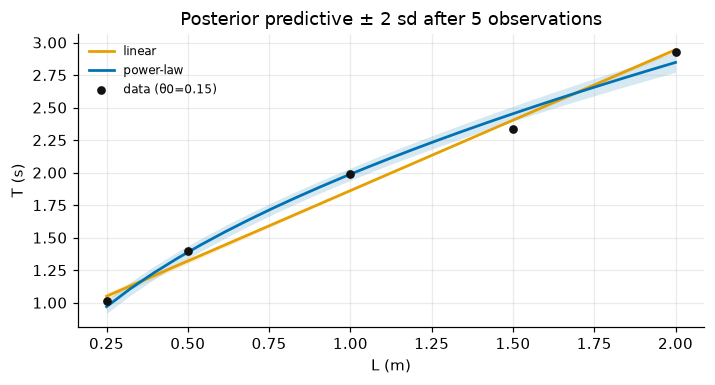

In [8]:
fig, ax = plt.subplots(figsize=(6.6, 3.6))
Ls = np.linspace(0.25, 2.0, 25)
for post in (post_lin, post_pow):
    col = C[post.hypothesis.name]
    mv = [post.predict(Design.from_dict({"L": l, "theta0": 0.15})) for l in Ls]
    m  = np.array([x[0][0] for x in mv])
    sd = np.sqrt([x[1][0] for x in mv])
    ax.plot(Ls, m, color=col, lw=1.8, label=post.hypothesis.name)
    ax.fill_between(Ls, m - 2*sd, m + 2*sd, color=col, alpha=0.16, lw=0)
ax.scatter([o.design["L"] for o in fit_data], [o.y[0] for o in fit_data],
           color=C["data"], s=22, zorder=5, label="data (θ0=0.15)")
ax.set(xlabel="L (m)", ylabel="T (s)", title="Posterior predictive ± 2 sd after 5 observations")
ax.legend(fontsize=8, frameon=False)
plt.tight_layout()

### The pool: a posterior over structures for free

`normalize_pool` softmaxes the log evidences: with a uniform prior over
structures, that **is** the posterior over structures. No extra machinery.

In [9]:
pool = normalize_pool([HypothesisState(h_lin, post_lin),
                       HypothesisState(h_pow, post_pow)])
for s in pool:
    print(f"P({s.hypothesis.name:<12}| data) = {np.exp(s.log_weight):.4f}")

P(linear      | data) = 0.0998
P(power-law   | data) = 0.9002


## 4 · Designer — value of information, the analytic Gaussian case

`Designer.choose(pool, candidates)` picks the next experiment. The paper's
analytic result for Gaussian noise: **run the design whose outcome the pool is
most uncertain about** — the posterior-predictive variance of the pool *mixture*:

$$\operatorname{Var}_{\text{mix}}(d) \;=\; \underbrace{\sum_k w_k\, v_k(d)}_{\text{within-structure}}
\;+\; \underbrace{\sum_k w_k\, m_k(d)^2 - \Bigl(\sum_k w_k\, m_k(d)\Bigr)^2}_{\text{between-structure disagreement}}$$

The between-term is what makes VoI seek *discriminating* experiments — sanity
check (c) verifies exactly this decomposition on a hand-computable case.

VoI would choose: L=2 th0=1.3


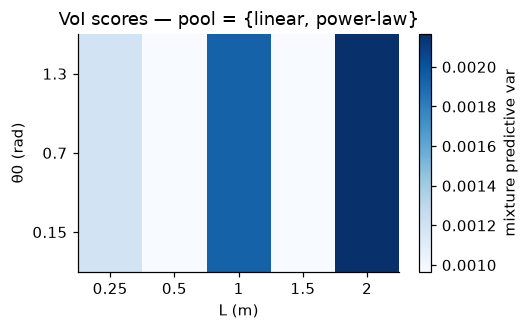

In [10]:
def mixture_prediction(pool, design):
    """Pool-mixture posterior-predictive mean/variance (law of total variance)."""
    w  = np.exp([s.log_weight for s in pool])
    ms = np.empty(len(pool)); vs = np.empty(len(pool))
    for i, s in enumerate(pool):
        m, v = s.posterior.predict(design)
        ms[i], vs[i] = m[0], v[0]
    mean = float(np.sum(w * ms))
    var  = max(float(np.sum(w * (vs + ms**2)) - mean**2), 0.0)
    return mean, var


@dataclass
class PoolVoIDesigner:
    """Analytic Gaussian VoI: argmax over candidates of mixture predictive
    variance; ties broken at random."""
    def scores(self, pool, candidates):
        return np.array([mixture_prediction(pool, d)[1] for d in candidates])
    def choose(self, pool, candidates, rng):
        s = self.scores(pool, candidates)
        return candidates[int(rng.choice(np.flatnonzero(s >= s.max() - 1e-12)))]

voi = PoolVoIDesigner()
assert isinstance(voi, Designer)


def voi_heatmap(pool, title, ax=None):
    cands = world.design_space()
    s = voi.scores(pool, cands).reshape(len(world.lengths), len(world.amplitudes))
    if ax is None:
        _, ax = plt.subplots(figsize=(4.9, 3.1))
    im = ax.imshow(s.T, origin="lower", aspect="auto", cmap="Blues")
    ax.set_xticks(range(len(world.lengths)), [f"{l:g}" for l in world.lengths])
    ax.set_yticks(range(len(world.amplitudes)), [f"{a:g}" for a in world.amplitudes])
    ax.set(xlabel="L (m)", ylabel="θ0 (rad)", title=title)
    ax.grid(False)
    plt.colorbar(im, ax=ax, label="mixture predictive var")

voi_heatmap(pool, "VoI scores — pool = {linear, power-law}")
plt.tight_layout()
print("VoI would choose:", voi.choose(pool, world.design_space(), np.random.default_rng(4)).name)

**Read the columns**: every column is constant in $\theta_0$. Neither hypothesis
in the pool *expresses* $\theta_0$, so VoI is structurally blind to it — it can
only seek disagreement the pool can already articulate. This is probe **P4**
(VoI under misspecification) in miniature, and it's why the M-open escape hatch
matters: something else has to notice that the pool is wrong.

## 5 · Proposer — where new structure enters

`Proposer.propose(context, data, pool, n_new)` supplies new candidate structures.
In the real system this is the **LLM** reading the domain description plus the
pool's residuals — or the **grammar enumerator** for probe P3 ("discovery or
recall?"). Here: a script that hands over the amplitude-corrected law when first
asked to expand, mimicking an LLM that looked at large-amplitude residuals.

In [11]:
@dataclass
class ScriptedExpansionProposer:
    ledger: Optional[CostLedger] = None
    calls: int = 0
    def propose(self, context, data, pool, n_new, rng):
        self.calls += 1
        if self.calls == 1:     # initial hypothesis set
            return [make_linear(self.ledger), make_power(self.ledger)]
        if self.calls == 2:     # first expansion request -> the "discovery"
            return [make_power_amp(self.ledger)]
        return []               # nothing further to offer

assert isinstance(ScriptedExpansionProposer(), Proposer)

## 6 · The loop — Algorithm 1, hand-rolled

`run_mda` in `agent.py` is Stage C's job; this cell is its spec in executable
form. One round, in sequence:

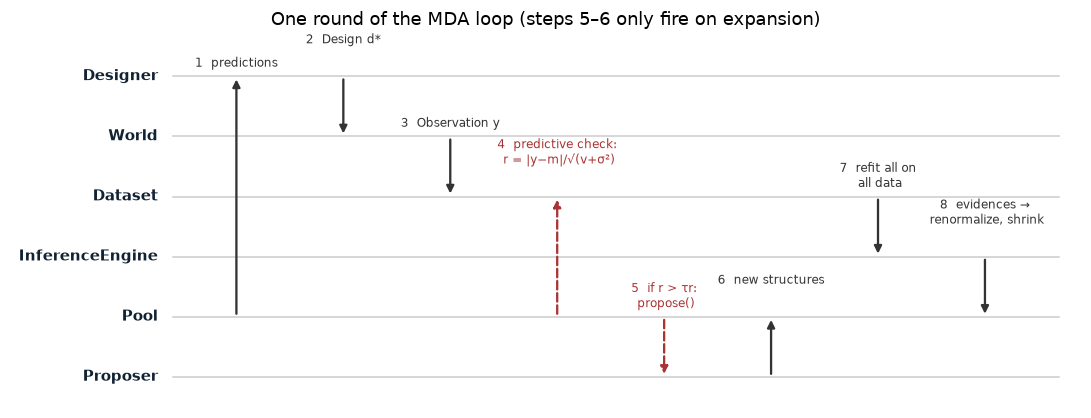

In [12]:
lanes = ["Designer", "World", "Dataset", "InferenceEngine", "Pool", "Proposer"]
ly = {n: len(lanes) - 1 - i for i, n in enumerate(lanes)}
fig, ax = plt.subplots(figsize=(10.2, 3.9))
ax.set_xlim(0, 10.2); ax.set_ylim(-0.5, len(lanes) - 0.4); ax.axis("off"); ax.grid(False)
for n, y in ly.items():
    ax.plot([1.55, 10.0], [y, y], color="#ccc", lw=1, zorder=1)
    ax.text(1.4, y, n, ha="right", va="center", fontsize=9.5, weight="bold", color="#123")

steps = [("Pool", "Designer",  "1  predictions",                 "#333", "-"),
         ("Designer", "World", "2  Design d*",                   "#333", "-"),
         ("World", "Dataset",  "3  Observation y",               "#333", "-"),
         ("Pool", "Dataset",   "4  predictive check:\n r = |y−m|/√(v+σ²)", "#a33", "--"),
         ("Pool", "Proposer",  "5  if r > τr:\n propose()",      "#a33", "--"),
         ("Proposer", "Pool",  "6  new structures",              "#333", "-"),
         ("Dataset", "InferenceEngine", "7  refit all on\n all data", "#333", "-"),
         ("InferenceEngine", "Pool", "8  evidences →\n renormalize, shrink", "#333", "-")]
for i, (a, b, lab, col, ls) in enumerate(steps):
    x = 2.15 + i * 1.02
    ax.annotate("", xy=(x, ly[b]), xytext=(x, ly[a]),
                arrowprops=dict(arrowstyle="-|>", color=col, lw=1.5, ls=ls))
    ax.text(x, max(ly[a], ly[b]) + (0.16 if i % 2 == 0 else 0.55), lab,
            ha="center", fontsize=7.6, color=col)
ax.set_title("One round of the MDA loop (steps 5–6 only fire on expansion)",
             fontsize=11.5, pad=10)
plt.tight_layout()

The **predictive check** (step 4): before updating on the new observation, score
it against the pool-mixture prediction — standardized residual
$r = |y - m_{\text{mix}}| \,/\, \sqrt{v_{\text{mix}} + \sigma^2}$. If $r > \tau_r$
the pool is declared inadequate → call the Proposer (**expansion**). Structures
whose pool weight collapses are dropped (**shrinking**). We use $\tau_r = 3$: a
"3σ surprise". Its exact form and threshold are probe **P5** — which is why the
check should stay a small injectable function in Stage C, not a buried constant.

In [13]:
config   = AgentConfig(budget=8, tau_r=3.0, n_particles=3000, n_propose=2)
loop_rng = np.random.default_rng(11)
ledger   = CostLedger()
engine   = PriorISEngine(n_samples=config.n_particles)
proposer = ScriptedExpansionProposer(ledger)
designer = PoolVoIDesigner()

# D0: two cheap small-angle observations to get started
data = [world.run(d, loop_rng) for d in
        (Design.from_dict({"L": 0.5, "theta0": 0.15}),
         Design.from_dict({"L": 1.5, "theta0": 0.15}))]
ledger.add_experiment(2)

hyps = proposer.propose(world.description(), data, [], config.n_propose, loop_rng)

def refit(hyps, data):
    return normalize_pool([HypothesisState(h, engine.fit(h, data, world.noise, loop_rng))
                           for h in hyps])

pool, rows = refit(hyps, data), []
for t in range(1, config.budget + 1):
    d   = designer.choose(pool, world.design_space(), loop_rng)     # 1-2
    obs = world.run(d, loop_rng); ledger.add_experiment()           # 3
    m, v = mixture_prediction(pool, d)                              # 4
    r    = abs(obs.y[0] - m) / np.sqrt(v + world.sigma**2)
    expanded = bool(r > config.tau_r)
    data.append(obs)
    if expanded:                                                    # 5-6
        hyps += proposer.propose(world.description(), data, pool,
                                 config.n_propose, loop_rng)
    pool = refit(hyps, data)                                        # 7-8
    dropped = [s.hypothesis.name for s in pool if s.log_weight < config.shrink_log_weight]
    if dropped:
        pool = normalize_pool([s for s in pool if s.log_weight >= config.shrink_log_weight])
        hyps = [s.hypothesis for s in pool]
    rows.append(dict(t=t, design=d.name, r=float(r), expanded=expanded, dropped=dropped,
                     ev={s.hypothesis.name: s.posterior.log_evidence for s in pool}))

print(f"{'t':>2}  {'design':<16}{'resid':>7}  {'expand':<7} evidences")
for row in rows:
    ev = "  ".join(f"{k} {v:8.1f}" for k, v in row["ev"].items())
    extra = f"   dropped: {', '.join(row['dropped'])}" if row["dropped"] else ""
    print(f"{row['t']:>2}  {row['design']:<16}{row['r']:>7.2f}  "
          f"{'YES' if row['expanded'] else '·':<7} {ev}{extra}")

 t  design            resid  expand  evidences
 1  L=0.25 th0=1.3     0.06  ·       linear     -4.1  power-law      0.1
 2  L=2 th0=0.15       1.04  ·       power-law      0.1   dropped: linear
 3  L=2 th0=1.3        4.39  YES     power-law-amp      0.0   dropped: power-law
 4  L=0.25 th0=0.15    0.33  ·       power-law-amp     -9.1
 5  L=2 th0=1.3        0.00  ·       power-law-amp     -6.5
 6  L=0.25 th0=0.15    1.97  ·       power-law-amp      1.7
 7  L=2 th0=1.3        0.33  ·       power-law-amp      1.9
 8  L=0.25 th0=1.3     0.44  ·       power-law-amp      3.6


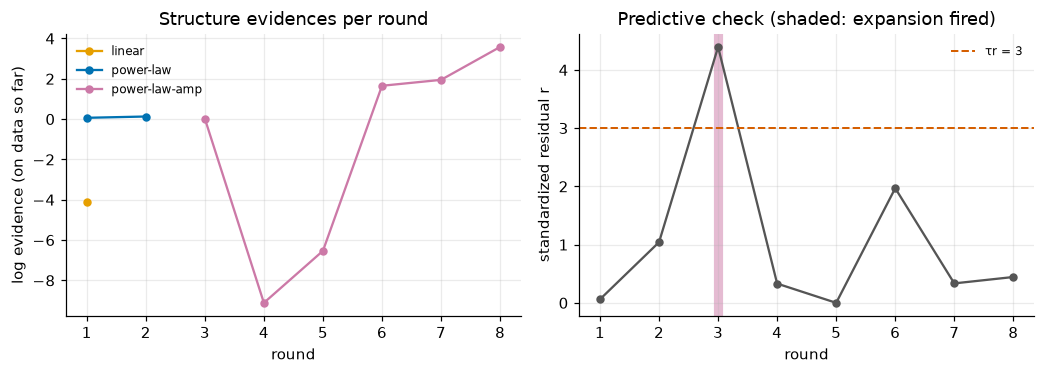

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.5))
for name in ("linear", "power-law", "power-law-amp"):
    pts = [(row["t"], row["ev"][name]) for row in rows if name in row["ev"]]
    if pts:
        axes[0].plot(*zip(*pts), marker="o", ms=4.5, color=C[name], label=name)
axes[0].set(xlabel="round", ylabel="log evidence (on data so far)",
            title="Structure evidences per round")
axes[0].legend(fontsize=8, frameon=False)

axes[1].plot([row["t"] for row in rows], [row["r"] for row in rows],
             marker="o", ms=4.5, color="#555")
axes[1].axhline(config.tau_r, color=C["threshold"], ls="--", lw=1.3,
                label=f"τr = {config.tau_r:g}")
for row in rows:
    if row["expanded"]:
        axes[1].axvline(row["t"], color=C["power-law-amp"], alpha=0.5, lw=6, zorder=0)
axes[1].set(xlabel="round", ylabel="standardized residual r",
            title="Predictive check (shaded: expansion fired)")
axes[1].legend(fontsize=8, frameon=False)
plt.tight_layout()

{'linear': 0.0, 'power-law': 0.0, 'power-law-amp': np.float64(1.0)}


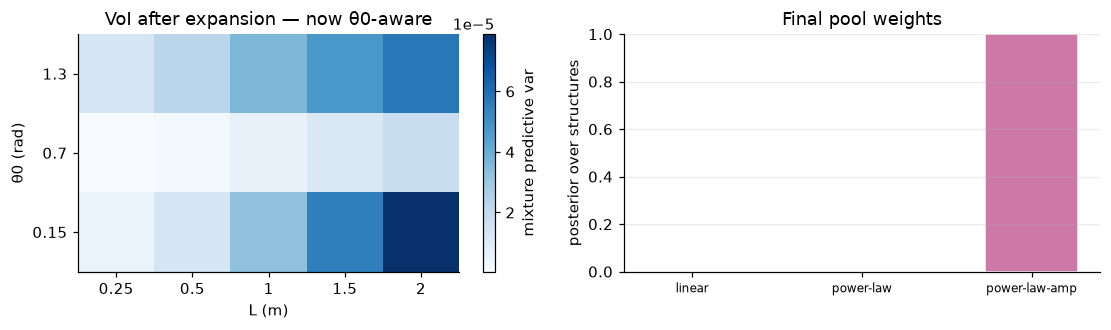

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.1))
voi_heatmap(pool, "VoI after expansion — now θ0-aware", ax=axes[0])
alive = {s.hypothesis.name: np.exp(s.log_weight) for s in pool}
w = {n: alive.get(n, 0.0) for n in ("linear", "power-law", "power-law-amp")}
axes[1].bar(list(w), list(w.values()), width=0.55,
            color=[C[n] for n in w], edgecolor="white")
axes[1].tick_params(axis="x", labelsize=8)
axes[1].set(ylabel="posterior over structures", ylim=(0, 1), title="Final pool weights")
axes[1].grid(axis="x")
plt.tight_layout()
print({k: round(v, 4) for k, v in w.items()})

Compare this heatmap with the pre-expansion one: the columns are no longer
constant — the $\theta_0 = 1.3$ row lights up because uncertainty in $c_2$ now
*expresses itself* at large amplitude (the shrunk pool has one structure left, so
what remains is within-structure parameter uncertainty; the zero-weight bars on
the right are what shrinking did). Discovery and design reinforcing each other —
new structure making new experiments informative — is the paper's one-sentence
thesis, and you just watched the mechanism do it.

## 7 · Evaluation — held-out interventions and the bill

The point of a mechanistic model is answering "what if" for interventions never
tried. `test_designs()` includes extrapolation in $L$ (the training grid stops at
2 m). The paper's ForceBench pass criterion is normalized MSE ≤ 0.1.

In [16]:
print(f"{'held-out design':<16}{'truth':>8}{'predicted':>11}{'± sd':>8}")
for d in world.test_designs():
    m, v = mixture_prediction(pool, d)
    print(f"{d.name:<16}{world._truth(d)[0]:>8.3f}{m:>11.3f}{np.sqrt(v):>8.3f}")

dense = [Design.from_dict({"L": L, "theta0": a})
         for L in np.linspace(0.3, 3.0, 10) for a in (0.15, 0.7, 1.3)]
preds  = np.array([mixture_prediction(pool, d)[0] for d in dense])
truths = np.array([world._truth(d)[0] for d in dense])
nmse   = float(np.mean((preds - truths)**2) / np.var(truths))
print(f"\ninterventional nMSE on dense held-out grid: {nmse:.4f}   (paper pass: <= 0.1)")
print(f"cost: {ledger.experiments_run} experiments (2 seed + {config.budget} designed), "
      f"{ledger.sim_calls:,} simulator calls, "
      f"{ledger.llm_prompt_tokens} LLM tokens (scripted proposer is free)")

held-out design    truth  predicted    ± sd
L=3 th0=0.15       3.479      3.486   0.011
L=3 th0=1.3        3.842      3.687   0.009
L=0.75 th0=1       1.846      1.820   0.001

interventional nMSE on dense held-out grid: 0.0065   (paper pass: <= 0.1)
cost: 10 experiments (2 seed + 8 designed), 828,000 simulator calls, 0 LLM tokens (scripted proposer is free)


## What was real, what was stubbed

| Notebook piece | Contract exercised | Real version (owner) |
|---|---|---|
| `PendulumWorld` | `World` | `worlds/`: drag projectile, Michaelis–Menten, NeuronBench adapter (Stage B-1) |
| `FormulaHypothesis` | `Hypothesis` | `hypotheses/`: sympy→JAX models (Stage B-3) |
| `PriorISEngine` — watch the ESS | `InferenceEngine` / `Posterior` | `inference/`: adaptive-tempered SMC (Stage B-2) |
| `PoolVoIDesigner` | `Designer` | `design/`: VoI + LLM/random baselines (Stage B-4) |
| `ScriptedExpansionProposer` | `Proposer` | `hypotheses/`: LLM proposer, grammar enumerator (Stage B-3) |
| hand-rolled loop | `run_mda` spec | `agent.py` (Stage C, one owner) |
| nMSE + ledger readout | — | `eval/`: metrics, tables (Stage B-4) |

And all four Phase-0 gate checks were previewed informally along the way:

* **(a) contraction** — prior-predictive spread of several seconds collapsing to
  ~0.01 s posterior-predictive sd on held-out designs by the end;
* **(b) Occam via evidence** — `power-law` beating `linear`, then `power-law-amp`
  beating `power-law` only *after* amplitude data justified the extra parameter;
* **(c) VoI** — the mixture-variance argmax, including its decomposition into
  within/between terms;
* **(d) expansion** — the τr trigger staying quiet on small-angle data and firing
  on the amplitude regime.

`tests/test_check_*.py` make each of these rigorous; un-skipping them against the
real components is the Phase-0 gate. Two probes also previewed themselves here:
**P4** (VoI is blind to structure the pool can't express) and **P5** (everything
hinged on one τr value).